# B2B Invoice Late-Payment Prediction Training Notebook

Goal : predict, at invoice issuance time, whether an invoice will be paid late
(`paid_late` = 0/1), so a credit-control team can prioritize follow-ups.

This notebook loads `invoices.csv`, explores it, trains a `RandomForestClassifier`
inside a sklearn `Pipeline`, evaluates it, and saves the fitted pipeline with the metadata
to `../api/model.pkl` for the FastAPI to load.

Here below are all the imported requirements for this project :

In [8]:
%matplotlib inline
import pathlib
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
RANDOM_STATE = 42

## 1. Load the dataset

In [2]:
df = pd.read_csv("invoices.csv")
print(f"Rows: {len(df)}")
df.head()

Rows: 6000


,invoice_amount,payment_terms_days,customer_tenure_months,customer_credit_score,previous_late_payments_count,avg_past_delay_days,number_of_open_invoices,discount_offered_pct,invoice_month,is_recurring_customer,sales_channel,weekday_issued,paid_late
0,4789.81,45,0.7,716.0,0,0.0,4,0,1,1,direct,0,0
1,1427.98,45,12.1,520.0,2,12.5,6,0,5,1,direct,3,0
2,7153.85,30,12.8,477.0,2,10.8,3,1,7,1,online,3,0
3,8488.85,60,15.1,545.0,2,1.6,1,3,8,0,online,3,0
4,628.96,45,28.3,837.0,2,10.1,5,0,5,0,direct,0,0


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
invoice_amount,6000.0,5430.952728,6065.759372,70.09,1972.405,3668.56,6481.8,81523.11
payment_terms_days,6000.0,38.380000,18.092268,15.00,30.000,30.00,45.0,90.00
customer_tenure_months,6000.0,24.017083,24.100065,0.00,7.000,16.60,32.8,225.20
customer_credit_score,6000.0,682.148833,87.423426,347.00,622.000,683.00,744.0,850.00
previous_late_payments_count,6000.0,1.197833,1.102526,0.00,0.000,1.00,2.0,6.00
avg_past_delay_days,6000.0,8.281250,8.829083,0.00,0.000,6.30,13.2,63.30
number_of_open_invoices,6000.0,3.016500,1.744153,0.00,2.000,3.00,4.0,10.00
discount_offered_pct,6000.0,0.989500,1.149613,0.00,0.000,0.00,2.0,3.00
invoice_month,6000.0,6.518333,3.418861,1.00,4.000,7.00,9.0,12.00
is_recurring_customer,6000.0,0.698667,0.458875,0.00,0.000,1.00,1.0,1.00


This table is a statistical summary of every numeric column and computes count, mean, standard deviation, min, max, and the 25th/50th/75th percentiles.

It's a fast way to check the data "sanity". For example, paid_late has a mean of 0.19, confirming ~19% of invoices are late, and customer_credit_score ranges from 347 to 850, matching real-world credit score bounds.

## 2. Exploratory analysis

The B2B invoice dataset needs some preparation. In this section, we visualize the data so it is clear on the first hand. We use barplots to separate the data into the two principal categories, and analyse each amount of feature present in the invoices.

/tmp/ipykernel_528/3171524137.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=["on_time", "late"], y=class_counts.values, palette="viridis")


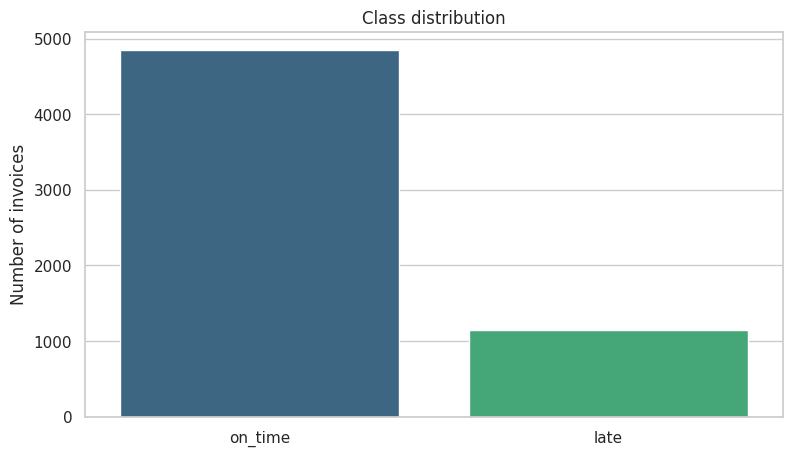

paid_late
0    0.808167
1    0.191833
Name: count, dtype: float64

In [4]:
class_counts = df["paid_late"].value_counts().sort_index()
ax = sns.barplot(x=["on_time", "late"], y=class_counts.values, palette="viridis")
ax.set_title("Class distribution")
ax.set_ylabel("Number of invoices")
plt.show()

class_counts / class_counts.sum()

The barplot above divides the invoices into 2 categories : the ones paid on time and the ones paid late. We see that ~19% of invoices are paid late. The classes are imbalanced, which is why the model
below uses `class_weight="balanced"`.

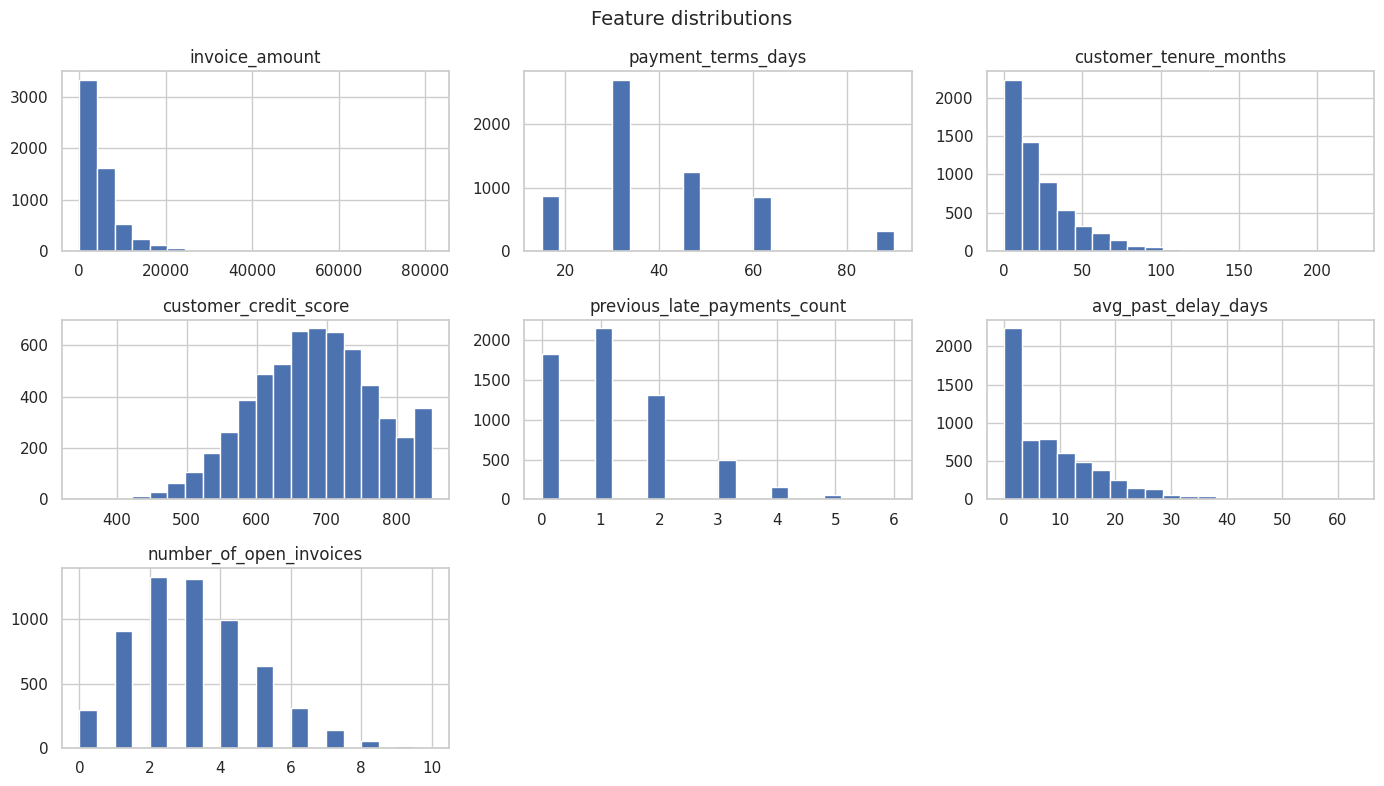

In [5]:
numeric_cols = [
    "invoice_amount",
    "payment_terms_days",
    "customer_tenure_months",
    "customer_credit_score",
    "previous_late_payments_count",
    "avg_past_delay_days",
    "number_of_open_invoices",
]
df[numeric_cols].hist(bins=20, figsize=(14, 8))
plt.suptitle("Feature distributions", fontsize=14)
plt.tight_layout()
plt.show()

This is a grid of histograms, one per numeric column in the dataset. Each individual chart answers the same question for one given variable : across all 6,000 invoices, how many fall into each range of values?

The x-axis is the value range of the studied variable, and the y-axis is the count of invoices landing in that bin. A taller bar means more invoices had that specific value.

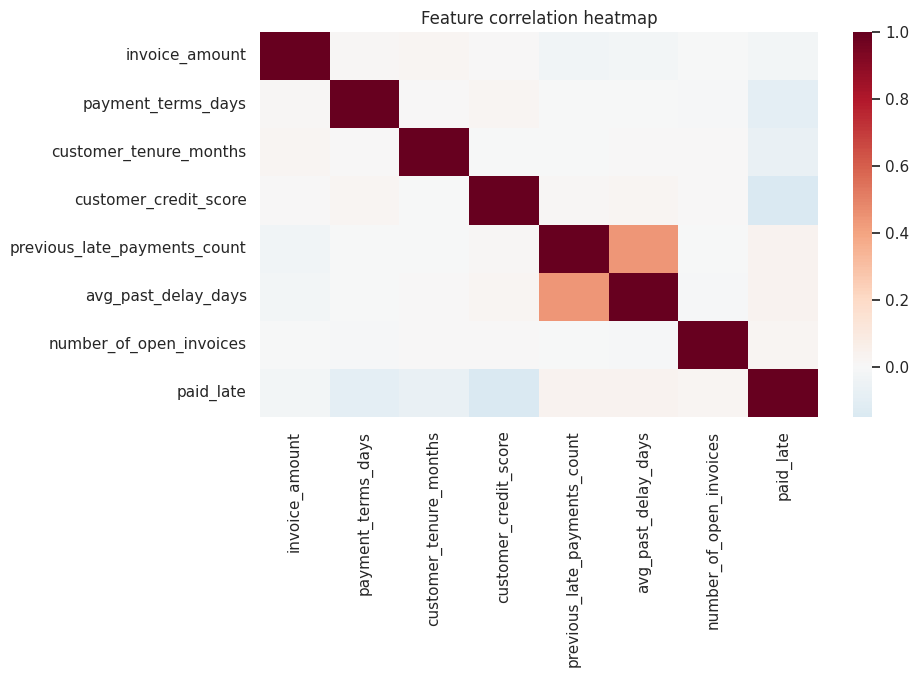

customer_credit_score          -0.150706
payment_terms_days             -0.096175
customer_tenure_months         -0.071298
previous_late_payments_count    0.040812
avg_past_delay_days             0.034650
invoice_amount                 -0.026062
number_of_open_invoices         0.020632
Name: paid_late, dtype: float64

In [6]:
corr = df[numeric_cols + ["paid_late"]].corr()
sns.heatmap(corr, cmap="RdBu_r", center=0, annot=False)
plt.title("Feature correlation heatmap")
plt.show()

# quick numeric look at what correlates most with the target
corr["paid_late"].drop("paid_late").sort_values(key=np.abs, ascending=False)

This correlation matrix shows how strongly each pair of numeric features moves together, from -1 to 1 according to the color scale on the right. The diagonal is always bright since each feature perfectly correlates with itself.

The one interesting off-diagonal pair is `previous_late_payments_count` and `avg_past_delay_days`, which are moderately correlated, which makes sense, since customers who've been late before also tend to have longer average delays. Most other pairs are near-zero, meaning the features are largely independent of each other.

## 3. Features and target

The data has to be split into a test and a training set. Here we target the paid_late label among the invoices, and we split the dataset into 4800 training invoices, and 1200 test invoices.

With the train set, the Random Forest model will be training the classification of on-time-paid and late-paid invoices, and with the test set, the model will be evaluated on the training.

In [9]:
TARGET = "paid_late"

NUMERIC_FEATURES = [
    "invoice_amount",
    "payment_terms_days",
    "customer_tenure_months",
    "customer_credit_score",
    "previous_late_payments_count",
    "avg_past_delay_days",
    "number_of_open_invoices",
    "discount_offered_pct",
    "invoice_month",
    "is_recurring_customer",
    "weekday_issued",
]
CATEGORICAL_FEATURES = ["sales_channel"]
FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
X_train.shape, X_test.shape

NameError: name 'df' is not defined

## 4. Preprocessing and model in a single Pipeline

- `StandardScaler` on the numeric features.
- `OneHotEncoder` on the categorical `sales_channel` feature.
- `RandomForestClassifier` as the classifier, with `class_weight="balanced"` to
  compensate for the ~19%/81% class imbalance.

Now we create the Random Forest model that will predict on-time or late payment for future invoices. It will be trained with the previously prepared dataset.

Bundling preprocessing and the model together means the exact same transformations used at training time are automatically re-applied at inference time. No train/serve skew when the API calls `.predict()` on raw input.

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERIC_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                max_depth=8,
                min_samples_leaf=5,
                class_weight="balanced",
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['invoice_amount',
                                                   'payment_terms_days',
                                                   'customer_tenure_months',
                                                   'customer_credit_score',
                                                   'previous_late_payments_count',
                                                   'avg_past_delay_days',
                                                   'number_of_open_invoices',
                                                   'discount_offered_pct',
                                                   'invoice_month',
                                                   'is_recurring_customer',
                                                   'weekday_issued']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['sales_channel'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_leaf=5, n_estimators=300,
                                        random_state=42))])

## 5. Evaluate on the test set

The second part of the prepared dataset is used on the model here : we test the trained model and measure the model's performances with metrics like accuracy, confusion matrix and the ROC AUC.

These metrics display the precision of the model, based on ratios of true positive/negative and false positive/negative.

In [9]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(classification_report(y_test, y_pred, target_names=["on_time", "late"]))
print(f"Accuracy: {accuracy:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")

              precision    recall  f1-score   support

     on_time       0.85      0.77      0.81       970
        late       0.31      0.43      0.36       230

    accuracy                           0.71      1200
   macro avg       0.58      0.60      0.59      1200
weighted avg       0.75      0.71      0.72      1200

Accuracy: 0.7075
ROC AUC:  0.6612


Here we obtained the model's classification report on the test set (1,200 invoices), breaking down performance separately for each class.

- For `on_time invoices` : precision 0.85, recall 0.77, thus when the model predicts "on_time," it's right 85% of the time, and it correctly catches 77% of all actually-on-time invoices.

- For `late invoices` : precision 0.31, recall 0.43, the model is much weaker here, correctly flagging late invoices only 43% of the time it should, and only 31% of its "late" predictions are actually correct.

Overall accuracy is 70.75%, but that number is misleading on its own since the classes are imbalanced (970 on-time vs. 230 late). A model that just guessed "on_time" every time would already score ~81% accuracy without being useful at all.

ROC AUC of 0.6612 is the more honest summary metric here because it measures how well the model ranks late-risk invoices above safe ones across all possible thresholds, which is independent of class imbalance. 0.66 is better than random guessing but well short of a strong model (0.85+), confirming this is a reasonable version, not yet production-grade at catching late payments.

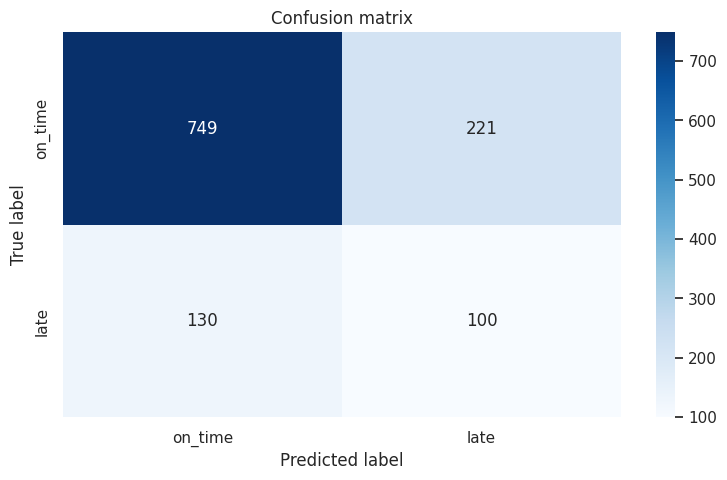

In [10]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["on_time", "late"], yticklabels=["on_time", "late"])
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion matrix")
plt.show()

This is a confusion matrix that shows how the model's predictions (**Predicted label**) compare to the actual outcomes on the test set (**True label**).

We see that 749 on-time invoices were correctly predicted as on-time, but 221 were wrongly flagged as late (**false positives**). And of the truly late invoices, only 100 were caught while 130 were missed (**false negatives**). It's the clearest picture that identifies where the model struggles. Here, it's still missing more late payments than it catches.

/tmp/ipykernel_528/3910072228.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importance.values[:8], y=feat_importance.index[:8], palette="mako")


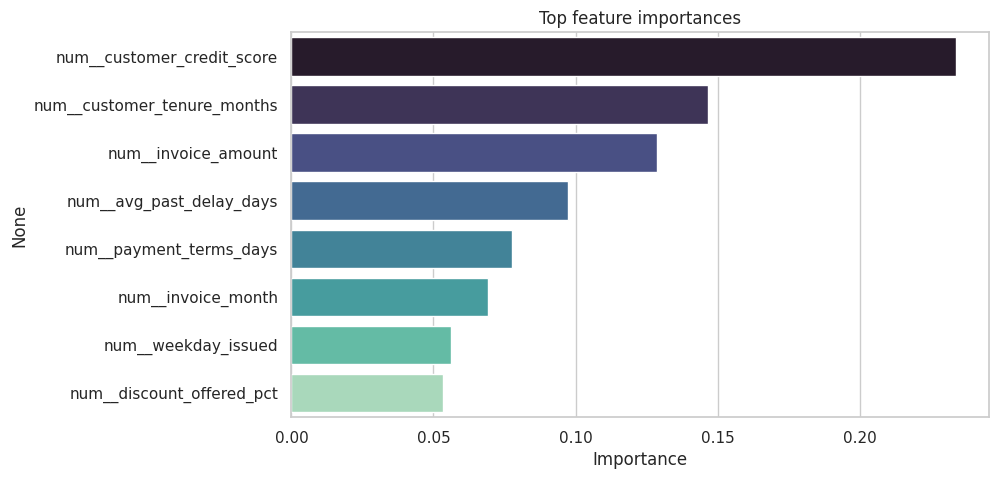

In [11]:
importances = model.named_steps["classifier"].feature_importances_
encoded_names = model.named_steps["preprocessor"].get_feature_names_out()
feat_importance = pd.Series(importances, index=encoded_names).sort_values(ascending=False)

sns.barplot(x=feat_importance.values[:8], y=feat_importance.index[:8], palette="mako")
plt.title("Top feature importances")
plt.xlabel("Importance")
plt.show()

This barplot reflects the importance of each feature when classifying a given invoice. In other words, which feature weights the heaviest on the balance.

`customer_credit_score` is by far the most influential, followed by `customer_tenure_months` and `invoice_amount`, which means that the model leans heavily on a customer's creditworthiness and relationship length rather than smaller signals like `discount_offered_pct`.

## 6. Persist the trained pipeline

Here I saved together with a bit of metadata (feature list, metrics, training timestamp) so the API can return it alongside each prediction.

In [5]:
MODEL_PATH = pathlib.Path("../api/model.pkl")
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

artifact = {
    "model": model,
    "features": FEATURES,
    "numeric_features": NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "sales_channel_categories": sorted(df["sales_channel"].unique().tolist()),
    "metrics": {"accuracy": round(float(accuracy), 4), "roc_auc": round(float(roc_auc), 4)},
    "trained_at": datetime.now(timezone.utc).isoformat(),
    "model_type": "RandomForestClassifier",
}

joblib.dump(artifact, MODEL_PATH)
print(f"Saved model artifact to {MODEL_PATH.resolve()}")

NameError: name 'model' is not defined

In [13]:
sample = X_test.iloc[[0]]
print(sample)
print("Predicted class:", model.predict(sample)[0])
print("Predicted probability of being late:", model.predict_proba(sample)[0, 1])

      invoice_amount  payment_terms_days  customer_tenure_months  \
4837         1456.53                  30                    42.2   

      customer_credit_score  previous_late_payments_count  \
4837                  564.0                             1   

      avg_past_delay_days  number_of_open_invoices  discount_offered_pct  \
4837                 14.7                        2                     2   

      invoice_month  is_recurring_customer  weekday_issued sales_channel  
4837              5                      0               0        direct  
Predicted class: 0
Predicted probability of being late: 0.3875773338407507


This is the end of the data preparation and model creation detail, see the README.md to deploy the model with FastAPI and Docker